# Census Income Prediction — ML Case Study

**Objective:** Predict whether an individual's annual income exceeds $50K, using
US census attributes. This is a **binary classification** problem (two outcomes:
`>50K` or `<=50K`).

## Step 1 — Imports

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

%matplotlib inline

## Step 2 — Load the Data

In [3]:
# Column names taken from the UCI Attribute Information page.
column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country",
    "income"  # target variable
]

train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
test_url  = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

# --- Training data ---
df = pd.read_csv(
    train_url,
    header=None,            # no header line in the file
    names=column_names,     # supply our own
    skipinitialspace=True,  # strip leading space after each comma
    na_values="?"           # treat "?" as missing
)

# --- Test data ---
df_test = pd.read_csv(
    test_url,
    header=None,
    names=column_names,
    skipinitialspace=True,
    na_values="?",
    skiprows=1              # skip the junk first line
)

# Strip trailing dot from test labels so they match the training labels
df_test["income"] = df_test["income"].str.replace(".", "", regex=False)

In [4]:
# Quick sanity checks
print("Train shape:", df.shape)
print("Test shape :", df_test.shape)
print("Train labels:", df["income"].unique())
print("Test  labels:", df_test["income"].unique())

df.head()

Train shape: (32561, 15)
Test shape : (16281, 15)
Train labels: <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str
Test  labels: <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Step 3 — Exploratory Data Analysis (EDA)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [6]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
df.describe(include="object")

C:\Users\mangl\AppData\Local\Temp\ipykernel_3004\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


income
<=50K    24720
>50K      7841
Name: count, dtype: int64
income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


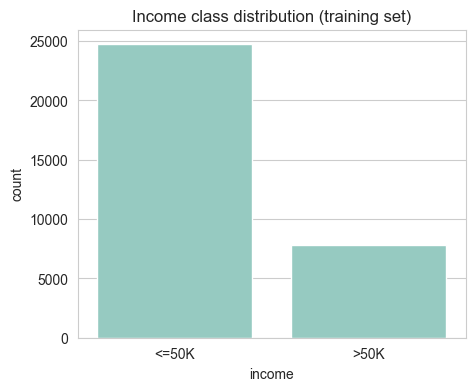

In [8]:
print(df["income"].value_counts())
print(df["income"].value_counts(normalize=True).round(3))   # as proportions

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="income")
plt.title("Income class distribution (training set)")
plt.show()

In [9]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_%": missing_pct}) \
    .query("missing_count > 0") \
    .sort_values("missing_%", ascending=False)

,missing_count,missing_%
occupation,1843,5.66
workclass,1836,5.64
native_country,583,1.79


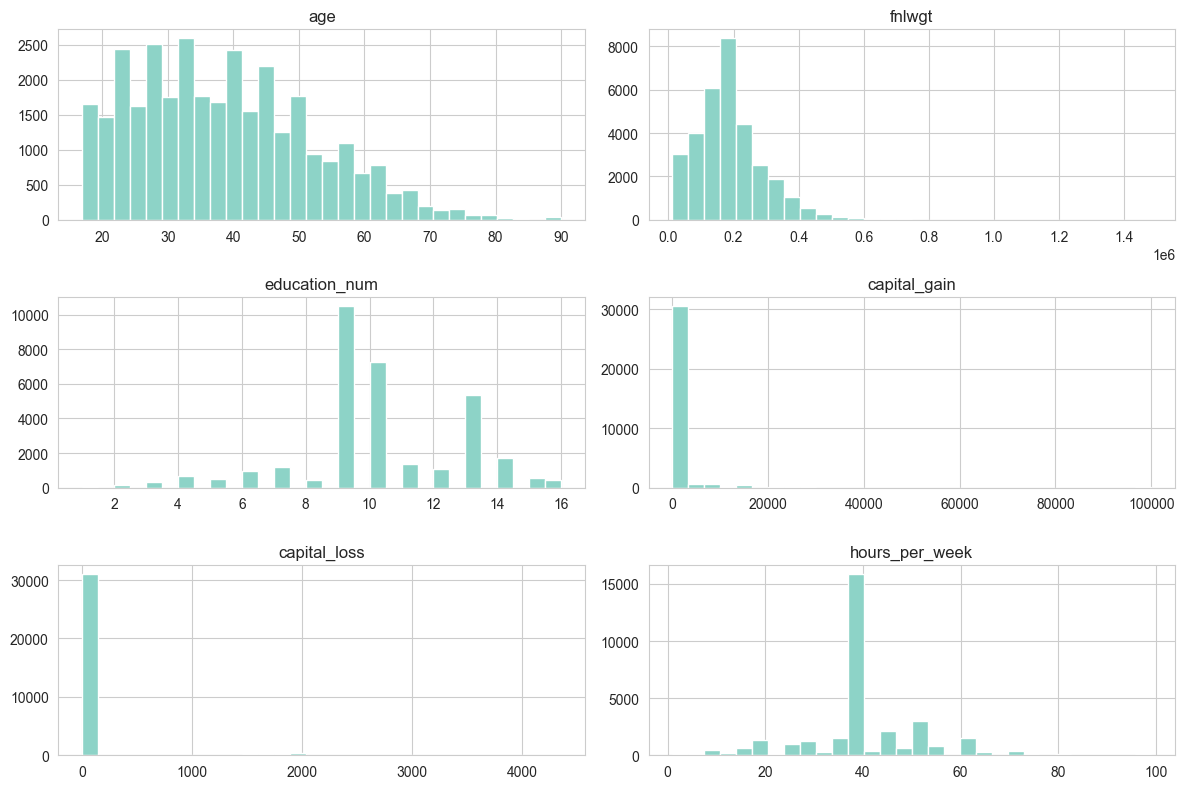

In [10]:
numeric_cols = ["age", "fnlwgt", "education_num",
                "capital_gain", "capital_loss", "hours_per_week"]

df[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

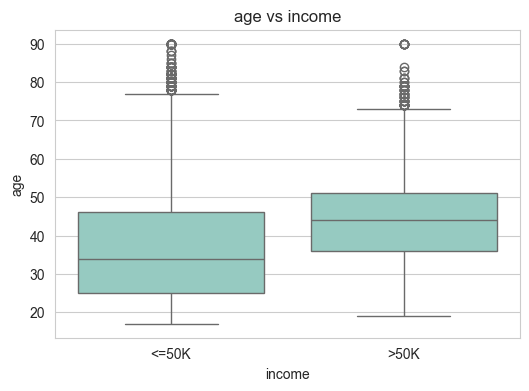

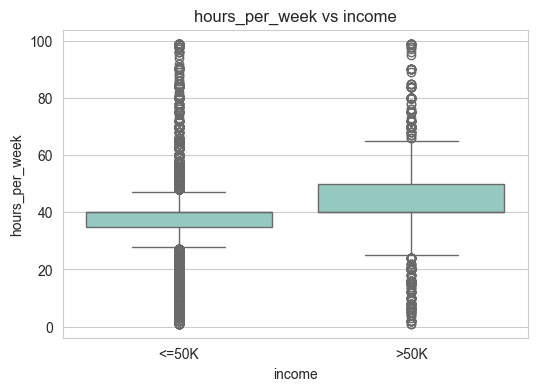

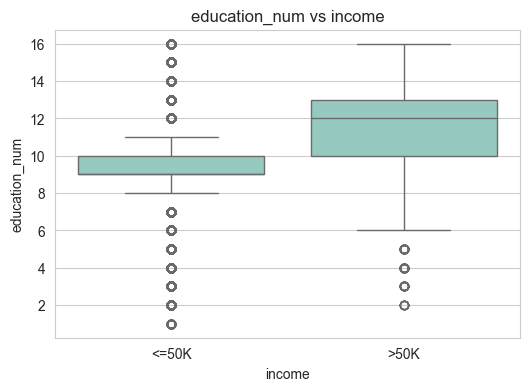

In [11]:
# How key numeric features differ by income bracket
for col in ["age", "hours_per_week", "education_num"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="income", y=col)
    plt.title(f"{col} vs income")
    plt.show()

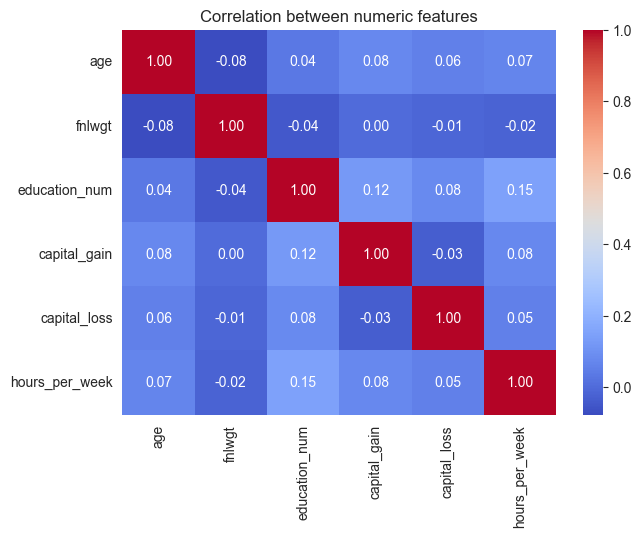

In [12]:
# Correlation among numeric features
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between numeric features")
plt.show()

In [13]:
cat_cols = df.select_dtypes(include="object").columns.drop("income")

for col in ["education", "marital_status", "occupation", "relationship", "sex"]:
    rates = pd.crosstab(df[col], df["income"], normalize="index")[">50K"] \
              .sort_values(ascending=False)
    print(f"\n--- Share earning >50K by {col} ---")
    print((rates * 100).round(1))


--- Share earning >50K by education ---
education
Doctorate       74.1
Prof-school     73.4
Masters         55.7
Bachelors       41.5
Assoc-voc       26.1
Assoc-acdm      24.8
Some-college    19.0
HS-grad         16.0
12th             7.6
10th             6.6
7th-8th          6.2
9th              5.3
11th             5.1
5th-6th          4.8
1st-4th          3.6
Preschool        0.0
Name: >50K, dtype: float64

--- Share earning >50K by marital_status ---
marital_status
Married-civ-spouse       44.7
Married-AF-spouse        43.5
Divorced                 10.4
Widowed                   8.6
Married-spouse-absent     8.1
Separated                 6.4
Never-married             4.6
Name: >50K, dtype: float64

--- Share earning >50K by occupation ---
occupation
Exec-managerial      48.4
Prof-specialty       44.9
Protective-serv      32.5
Tech-support         30.5
Sales                26.9
Craft-repair         22.7
Transport-moving     20.0
Adm-clerical         13.4
Machine-op-inspct    12.5
F

C:\Users\mangl\AppData\Local\Temp\ipykernel_3004\3458191461.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.drop("income")


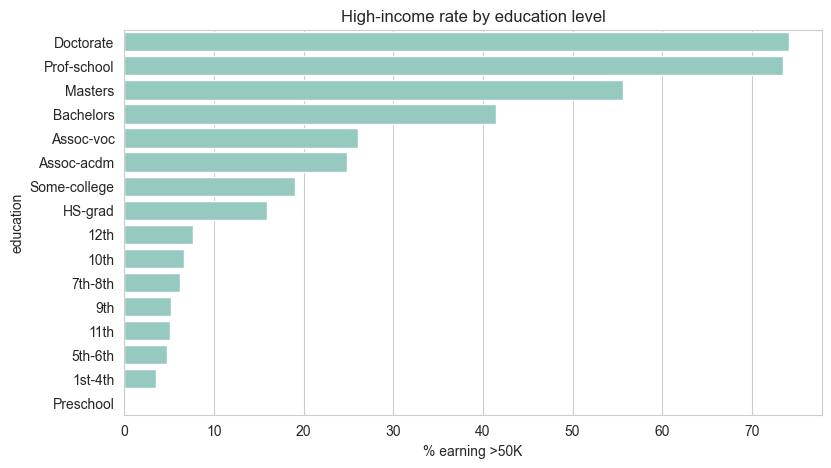

In [14]:
# Visual example: >50K rate by education level
plt.figure(figsize=(9, 5))
edu_rate = pd.crosstab(df["education"], df["income"], normalize="index")[">50K"] \
             .sort_values(ascending=False)
sns.barplot(x=edu_rate.values * 100, y=edu_rate.index)
plt.xlabel("% earning >50K")
plt.title("High-income rate by education level")
plt.show()

## Step 4 — Cleaning & Preprocessing

In [15]:
drop_cols = ["fnlwgt", "education"]

df       = df.drop(columns=drop_cols)
df_test  = df_test.drop(columns=drop_cols)

df.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [16]:
X_train = df.drop(columns=["income"])
y_train = (df["income"] == ">50K").astype(int)   # 1 = high earner, 0 = not

X_test  = df_test.drop(columns=["income"])
y_test  = (df_test["income"] == ">50K").astype(int)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Positive class rate (train):", round(y_train.mean(), 3))

X_train: (32561, 12) | X_test: (16281, 12)
Positive class rate (train): 0.241


In [17]:
numeric_features     = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


C:\Users\mangl\AppData\Local\Temp\ipykernel_3004\1933572747.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include="object").columns.tolist()


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numeric pipeline: fill missing -> scale
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline: fill missing -> one-hot encode
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # NOTE: use sparse_output=False (modern). The old `sparse=` arg is DEPRECATED.
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine into one preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor   # display it

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Step 5 — Modelling

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model 1: Logistic Regression (linear baseline)
logreg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,            # enough iterations to converge
        class_weight="balanced",  # handle the imbalanced target
        random_state=42
    ))
])

# Model 2: Random Forest (non-linear ensemble)
rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,         # number of trees
        min_samples_leaf=5,       # overfitting guard: no leaf smaller than 5 samples
        class_weight="balanced",
        n_jobs=-1,                # use all CPU cores
        random_state=42
    ))
])

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

for name, model in [("Logistic Regression", logreg), ("Random Forest", rf)]:
    results = cross_validate(
        model, X_train, y_train,
        cv=cv, scoring=scoring,
        return_train_score=True,   # to detect overfitting
        n_jobs=-1
    )
    print(f"\n===== {name} =====")
    for metric in scoring:
        val   = results["test_"  + metric].mean()
        train = results["train_" + metric].mean()
        print(f"  {metric:10s} | val: {val:.3f} | train: {train:.3f} | gap: {train - val:+.3f}")


===== Logistic Regression =====
  accuracy   | val: 0.807 | train: 0.809 | gap: +0.002
  precision  | val: 0.567 | train: 0.570 | gap: +0.003
  recall     | val: 0.846 | train: 0.849 | gap: +0.003
  f1         | val: 0.679 | train: 0.682 | gap: +0.003
  roc_auc    | val: 0.905 | train: 0.907 | gap: +0.002

===== Random Forest =====
  accuracy   | val: 0.818 | train: 0.831 | gap: +0.013
  precision  | val: 0.583 | train: 0.601 | gap: +0.018
  recall     | val: 0.858 | train: 0.889 | gap: +0.031
  f1         | val: 0.694 | train: 0.717 | gap: +0.023
  roc_auc    | val: 0.916 | train: 0.934 | gap: +0.018


In [21]:
logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)
print("Both models trained on full training set. ✅")

Both models trained on full training set. ✅


## Step 6 — Model Evaluation (held-out test set)

In [22]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, roc_auc_score
)

models = {"Logistic Regression": logreg, "Random Forest": rf}

for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]   # probability of class 1 (>50K)
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, digits=3,
                                target_names=["<=50K", ">50K"]))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")


===== Logistic Regression =====
              precision    recall  f1-score   support

       <=50K      0.941     0.795     0.862     12435
        >50K      0.559     0.840     0.671      3846

    accuracy                          0.806     16281
   macro avg      0.750     0.818     0.767     16281
weighted avg      0.851     0.806     0.817     16281

ROC-AUC: 0.903

===== Random Forest =====
              precision    recall  f1-score   support

       <=50K      0.948     0.808     0.872     12435
        >50K      0.580     0.856     0.691      3846

    accuracy                          0.819     16281
   macro avg      0.764     0.832     0.782     16281
weighted avg      0.861     0.819     0.830     16281

ROC-AUC: 0.915


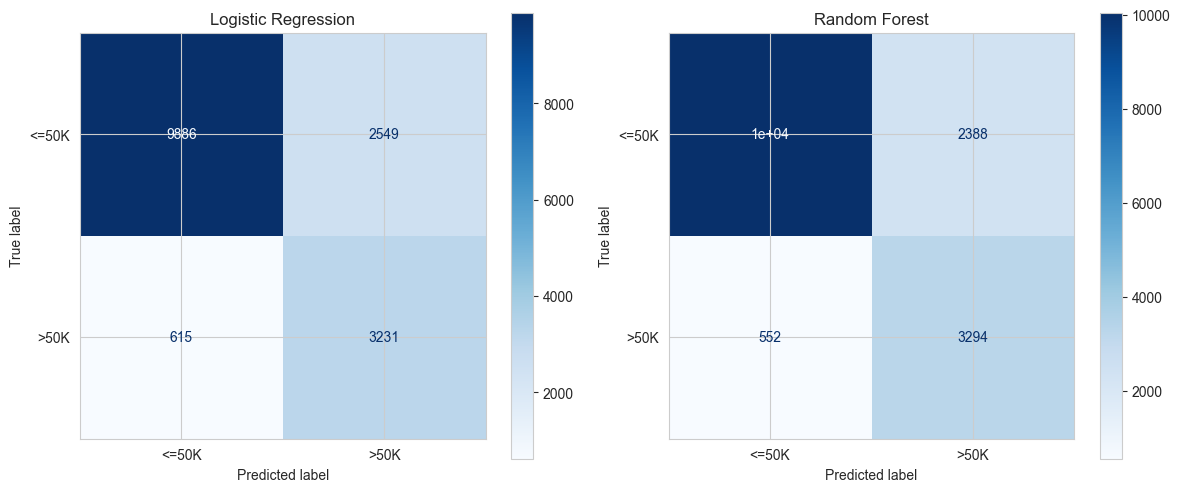

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, ax=ax, cmap="Blues",
        display_labels=["<=50K", ">50K"]
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

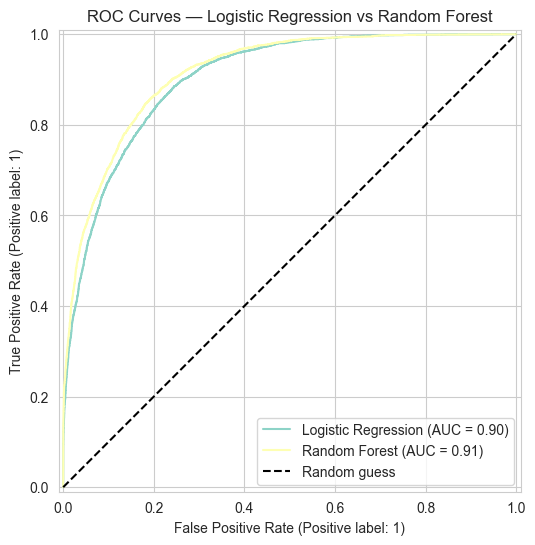

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--", label="Random guess")
ax.set_title("ROC Curves — Logistic Regression vs Random Forest")
ax.legend()
plt.show()

## Step 7 — Model Comparison & Selection

In [25]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

rows = []
for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(rows).set_index("Model").round(3)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.806,0.559,0.840,0.671,0.903
Random Forest,0.819,0.580,0.856,0.691,0.915


## Step 8 — Business Analysis & Visualisations

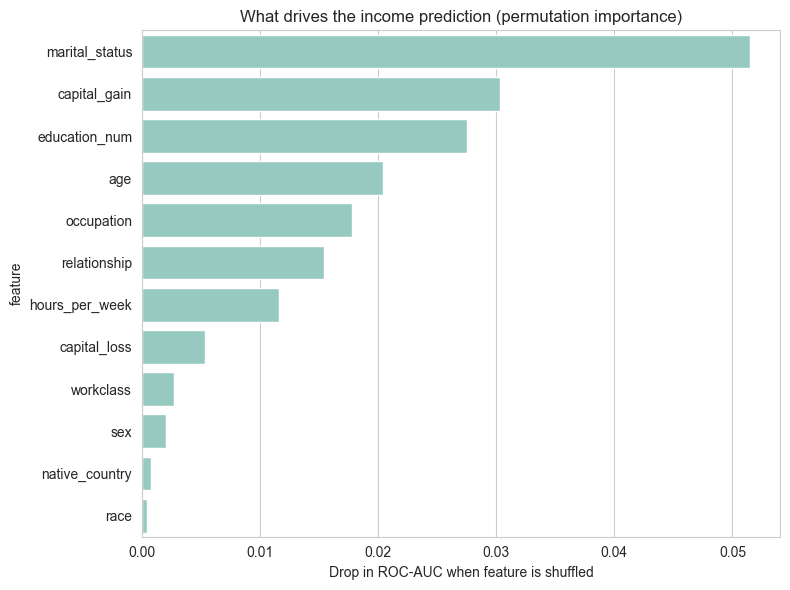

In [26]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=5, random_state=42, n_jobs=-1, scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_df, x="importance", y="feature")
plt.title("What drives the income prediction (permutation importance)")
plt.xlabel("Drop in ROC-AUC when feature is shuffled")
plt.tight_layout()
plt.show()